# National AI Strategy — Text Analysis (G7 + China + EU)

Comparative text analysis of National AI Strategy documents:

- `CA_National_AI_Strategy_ocr.pdf` — Canada
- `CN_National_AI_Strategy.pdf` — China
- `DE_National_AI_Strategy.pdf` — Germany
- `EU_AI_Strategy.pdf` — European Union
- `FR__National_AI_Strategy.pdf` — France
- `FR__National_AI_Strategy-2.pdf` — France
- `IT_National_AI_Strategy.pdf` — Italy
- `JP_National_AI_Strategy_ocr.pdf` — Japan
- `UK_National_AI_Strategy_ocr.pdf` — United Kingdom
- `US_National_AI_Strategy.pdf` — United States
- `国务院关于深入实施“人工智能+”行动的意见.pdf` — China

Source PDFs are downloaded from Google Drive folder `https://drive.google.com/drive/folders/1CCiBmppafwtXLRVTpnryIY8Y9PLvxwvG` into [`data/pdf/AI Policy/`](../../data/pdf/AI%20Policy/).

## Required Packages

```bash
pip install gdown pdfplumber scikit-learn matplotlib pandas seaborn plotly ipywidgets transformers torch sentencepiece wordcloud nltk
```


## 1. Setup

In [27]:
from pathlib import Path
import sys

repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'data').is_dir() and (p / 'src').is_dir()
)
src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pdfplumber
import gdown

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation

from ai_policy.common import find_repo_root, STRATEGY_COUNTRY_MAP

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Serif CJK SC', 'DejaVu Sans']

repo_root = find_repo_root(Path.cwd())
pdf_dir = repo_root / 'data' / 'pdf' / 'AI Policy'
pdf_dir.mkdir(parents=True, exist_ok=True)

DRIVE_FOLDER_URL = 'https://drive.google.com/drive/folders/1CCiBmppafwtXLRVTpnryIY8Y9PLvxwvG'
SYNC_GOOGLE_DRIVE = True

if SYNC_GOOGLE_DRIVE:
    print('Syncing PDF files from Google Drive...')
    try:
        gdown.download_folder(
            url=DRIVE_FOLDER_URL,
            output=str(pdf_dir),
            quiet=False,
            use_cookies=False,
            remaining_ok=True,
        )
    except TypeError:
        # Older gdown versions do not support remaining_ok.
        gdown.download_folder(
            url=DRIVE_FOLDER_URL,
            output=str(pdf_dir),
            quiet=False,
            use_cookies=False,
        )
else:
    print('Google Drive sync skipped. Set SYNC_GOOGLE_DRIVE = True to check for new files.')

pdf_files = sorted(pdf_dir.glob('*.pdf'))
expected_pdfs = sorted(STRATEGY_COUNTRY_MAP)
missing_pdfs = [name for name in expected_pdfs if not (pdf_dir / name).exists()]
unmapped_pdfs = [pdf.name for pdf in pdf_files if pdf.name not in STRATEGY_COUNTRY_MAP]

print('\n' + '=' * 60)
print('Repository Information')
print('=' * 60)

print(f'Repo root : {repo_root}')
print(f'PDF dir   : {pdf_dir}')
print(f'PDF count : {len(pdf_files)}')
print(f'Drive URL : {DRIVE_FOLDER_URL}')

if missing_pdfs:
    print('\nWarning: missing expected PDF files after download attempt:')
    for name in missing_pdfs:
        print(f' - {name}')

if unmapped_pdfs:
    print('\nNew or unmapped PDF files detected. Add these to EXTRA_COUNTRY_MAP in the next cell to include them in analysis:')
    for name in unmapped_pdfs:
        print(f"    '{name}': 'Country or Entity Name',")

print('\nPDF Files:')
for pdf in pdf_files:
    mapped = 'mapped' if pdf.name in STRATEGY_COUNTRY_MAP else 'unmapped'
    print(f' - {pdf.name} [{mapped}]')


Syncing PDF files from Google Drive...


Retrieving folder contents


Processing file 1Nj0a2PqDyv0I7-OO2uA98aI16S6meAAR CA_National_AI_Strategy.pdf
Processing file 1YxhhsgZPLibz9YWBGpK2PDy2fo3ZY7u4 CN_National_AI_Strategy.pdf
Processing file 1w2Y_uFKsJqfTFZ5tFTc8crSxwMVtevvH DE_National_AI_Strategy.pdf
Processing file 1iTX057sVHB8HeQvaITQ9s5OQFvhbbXko EU_AI_Strategy.pdf
Processing file 1t7qIM7xYsXu2Ze0kb-HIABj7Jq-r37bA FR__National_AI_Strategy.pdf
Processing file 1ZOB-iyQh4t4UJgyAYHdJlWs4IMibJFsI FR_National_AI_Strategy_2.pdf
Processing file 1ED_C6m2DJ6XQJSL1IU_eDATweKU5k2lq IT_National_AI_Strategy.pdf
Processing file 1KBPAOWWIZXwvft9nBkvTsb20Zp7AA4ZS JP_National_AI_Strategy.pdf
Processing file 1vZMeeK-5eiNfckhGZFSbr-YtTlgmYxq8 UK_National_AI_Strategy.pdf
Processing file 1kaLgQDtYlFzzX3KQ8yz03vqM-9e_lqb_ US_National_AI_Strategy.pdf
Processing file 1lW94YylmV7PO3kMdzIt15Mx52fgdpxsq 国务院关于深入实施“人工智能+”行动的意见.pdf


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Nj0a2PqDyv0I7-OO2uA98aI16S6meAAR
To: /home/wucheng/AI-Policy/data/pdf/AI Policy/CA_National_AI_Strategy.pdf
100%|██████████| 6.16M/6.16M [00:01<00:00, 4.70MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YxhhsgZPLibz9YWBGpK2PDy2fo3ZY7u4
To: /home/wucheng/AI-Policy/data/pdf/AI Policy/CN_National_AI_Strategy.pdf
100%|██████████| 756k/756k [00:00<00:00, 2.85MB/s]
Downloading...
From: https://drive.google.com/uc?id=1w2Y_uFKsJqfTFZ5tFTc8crSxwMVtevvH
To: /home/wucheng/AI-Policy/data/pdf/AI Policy/DE_National_AI_Strategy.pdf
100%|██████████| 1.16M/1.16M [00:00<00:00, 2.96MB/s]
Downloading...
From: https://drive.google.com/uc?id=1iTX057sVHB8HeQvaITQ9s5OQFvhbbXko
To: /home/wucheng/AI-Policy/data/pdf/AI Policy/EU_AI_Strategy.pdf
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
Downloading...
From: https://drive.google.com/uc?i


Repository Information
Repo root : /home/wucheng/AI-Policy
PDF dir   : /home/wucheng/AI-Policy/data/pdf/AI Policy
PDF count : 14
Drive URL : https://drive.google.com/drive/folders/1CCiBmppafwtXLRVTpnryIY8Y9PLvxwvG

New or unmapped PDF files detected. Add these to EXTRA_COUNTRY_MAP in the next cell to include them in analysis:
    'CA_National_AI_Strategy.pdf': 'Country or Entity Name',
    'FR_National_AI_Strategy_2.pdf': 'Country or Entity Name',
    'JP_National_AI_Strategy.pdf': 'Country or Entity Name',
    'UK_National_AI_Strategy.pdf': 'Country or Entity Name',

PDF Files:
 - CA_National_AI_Strategy.pdf [unmapped]
 - CA_National_AI_Strategy_ocr.pdf [mapped]
 - CN_National_AI_Strategy.pdf [mapped]
 - DE_National_AI_Strategy.pdf [mapped]
 - EU_AI_Strategy.pdf [mapped]
 - FR_National_AI_Strategy_2.pdf [unmapped]
 - FR__National_AI_Strategy.pdf [mapped]
 - IT_National_AI_Strategy.pdf [mapped]
 - JP_National_AI_Strategy.pdf [unmapped]
 - JP_National_AI_Strategy_ocr.pdf [mapped]
 - UK


Download completed


## 2. Country Mapping

In [28]:
from ai_policy.common import (
    STRATEGY_COLORS as COLORS,
    STRATEGY_COUNTRY_MAP,
    country_subplot_grid,
)

# Add newly downloaded Google Drive PDFs here when the setup cell reports them as unmapped.
# Example:
# EXTRA_COUNTRY_MAP = {
#     'NEW_AI_Strategy.pdf': 'New Country',
# }
EXTRA_COUNTRY_MAP = {}

COUNTRY_MAP = {**STRATEGY_COUNTRY_MAP, **EXTRA_COUNTRY_MAP}

if EXTRA_COUNTRY_MAP:
    print('Extra PDF mappings added:')
    for pdf_name, country in EXTRA_COUNTRY_MAP.items():
        print(f' - {pdf_name}: {country}')
else:
    print('No extra PDF mappings added.')



No extra PDF mappings added.


## 3. Extract Text from PDFs

Uses `pdfplumber`. Returns a dict `{country: full_text}`.


In [29]:
from ai_policy.text_utils import extract_pdf_text

texts = {}
page_counts = {}
source_files = {}

for pdf_name, country in COUNTRY_MAP.items():
    pdf_path = pdf_dir / pdf_name
    if not pdf_path.exists():
        print(f'Warning: missing PDF for {country}: {pdf_path.name}')
        continue

    text = extract_pdf_text(pdf_path)
    with pdfplumber.open(pdf_path) as p:
        pages = len(p.pages)

    if country in texts:
        texts[country] += f'\n\n--- Source: {pdf_path.name} ---\n\n{text}'
        page_counts[country] += pages
        source_files[country].append(pdf_path.name)
    else:
        texts[country] = text
        page_counts[country] = pages
        source_files[country] = [pdf_path.name]

    print(f'{country:15s}  {pages:>4d} pages, {len(text):>8,} chars  ({pdf_path.name})')

print('\nAggregated documents:')
for country in texts:
    print(f'{country:15s}  {page_counts[country]:>4d} total pages, {len(texts[country]):>8,} total chars, {len(source_files[country])} source file(s)')

low_text_docs = {
    country: len(text)
    for country, text in texts.items()
    if len(text.strip()) < 1000
}

if low_text_docs:
    print('\nWarning: Some PDFs have very little extractable text.')
    print('These files may be scanned/image-based PDFs and may need OCR before text analysis:')
    for country, char_count in low_text_docs.items():
        print(f'  - {country}: {char_count:,} extracted characters')


Canada             27 pages,   54,816 chars  (CA_National_AI_Strategy_ocr.pdf)
China              18 pages,   27,582 chars  (CN_National_AI_Strategy.pdf)
Germany            31 pages,  101,100 chars  (DE_National_AI_Strategy.pdf)
European Union     66 pages,  229,358 chars  (EU_AI_Strategy.pdf)
France             30 pages,   42,286 chars  (FR__National_AI_Strategy.pdf)
Italy              38 pages,  127,506 chars  (IT_National_AI_Strategy.pdf)
Japan              17 pages,   43,336 chars  (JP_National_AI_Strategy_ocr.pdf)
United Kingdom     28 pages,   61,665 chars  (UK_National_AI_Strategy_ocr.pdf)


Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because No

United States      28 pages,   68,715 chars  (US_National_AI_Strategy.pdf)


Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because No

China               3 pages,    5,431 chars  (国务院关于深入实施“人工智能+”行动的意见.pdf)

Aggregated documents:
Canada             27 total pages,   54,816 total chars, 1 source file(s)
China              21 total pages,   33,058 total chars, 2 source file(s)
Germany            31 total pages,  101,100 total chars, 1 source file(s)
European Union     66 total pages,  229,358 total chars, 1 source file(s)
France             30 total pages,   42,286 total chars, 1 source file(s)
Italy              38 total pages,  127,506 total chars, 1 source file(s)
Japan              17 total pages,   43,336 total chars, 1 source file(s)
United Kingdom     28 total pages,   61,665 total chars, 1 source file(s)
United States      28 total pages,   68,715 total chars, 1 source file(s)


## 4. Document Statistics

In [30]:
from ai_policy.text_utils import word_tokenize

stats = []
for country, text in texts.items():
    tokens = word_tokenize(text)
    stats.append({
        'Country': country,
        'Source files': '; '.join(source_files.get(country, [])),
        'Pages': page_counts[country],
        'Characters': len(text),
        'Words/CJK chars': len(tokens),
        'Unique tokens': len(set(tokens)),
        'Type-token ratio': round(len(set(tokens)) / max(len(tokens), 1), 3),
    })

stats_df = pd.DataFrame(stats).set_index('Country')
print('Document statistics:')
stats_df


Document statistics:


,Source files,Pages,Characters,Words/CJK chars,Unique tokens,Type-token ratio
Country,,,,,,
Canada,CA_National_AI_Strategy_ocr.pdf,27,54816,6602,1571,0.238
China,CN_National_AI_Strategy.pdf; 国务院关于深入实施“人工智能+”行...,21,33058,7684,1559,0.203
Germany,DE_National_AI_Strategy.pdf,31,101100,11608,2059,0.177
European Union,EU_AI_Strategy.pdf,66,229358,26479,2997,0.113
France,FR__National_AI_Strategy.pdf,30,42286,4870,1622,0.333
Italy,IT_National_AI_Strategy.pdf,38,127506,14917,2986,0.200
Japan,JP_National_AI_Strategy_ocr.pdf,17,43336,4821,1149,0.238
United Kingdom,UK_National_AI_Strategy_ocr.pdf,28,61665,7349,1840,0.250
United States,US_National_AI_Strategy.pdf,28,68715,7756,1905,0.246


## 5. NLLB Translation to English

Optional robustness-check translation using `facebook/nllb-200-distilled-600M`. CJK-heavy paragraphs are translated into English and existing English paragraphs are left unchanged, then translated country texts are saved for follow-up analysis.

In [31]:
# NLLB translation is cached on disk after the first run.
# Set to False if you want to skip model loading during exploratory notebook runs.
RUN_NLLB_TRANSLATION = True
NLLB_MODEL_NAME = 'facebook/nllb-200-distilled-600M'
NLLB_SOURCE_LANG = 'zho_Hans'
NLLB_TARGET_LANG = 'eng_Latn'

translated_dir = repo_root / 'data' / 'pdf' / 'AI Policy' / '_translated_nllb'
translated_dir.mkdir(parents=True, exist_ok=True)


from ai_policy.text_utils import cjk_ratio, load_nllb, split_translation_units, translate_units_nllb

translation_stats = []
nllb_tokenizer = nllb_model = nllb_device = None

if RUN_NLLB_TRANSLATION:
    for country, text in texts.items():
        units = split_translation_units(text, 700)
        cjk_units = sum(cjk_ratio(unit) >= 0.20 for unit in units)
        out_path = translated_dir / f'{country}.txt'

        if cjk_units == 0:
            status = 'skipped_no_cjk'
        elif out_path.exists():
            status = 'cached'
        else:
            if nllb_tokenizer is None:
                print(f'Loading {NLLB_MODEL_NAME}...')
                nllb_tokenizer, nllb_model, nllb_device = load_nllb(NLLB_MODEL_NAME, NLLB_SOURCE_LANG)
                print(f'NLLB device: {nllb_device}')
            print(f'Translating {country}: {cjk_units}/{len(units)} CJK-heavy units')
            translated_text = '\n\n'.join(
                translate_units_nllb(
                    units,
                    nllb_tokenizer,
                    nllb_model,
                    nllb_device,
                    NLLB_TARGET_LANG,
                    0.20,
                    512,
                )
            )
            out_path.write_text(translated_text, encoding='utf-8')
            status = 'translated'

        translation_stats.append({
            'Country': country,
            'Source files': '; '.join(source_files.get(country, [])),
            'Translation file': out_path.name if cjk_units > 0 else '',
            'Units': len(units),
            'CJK-heavy units': cjk_units,
            'Status': status,
        })

    translation_stats_df = pd.DataFrame(translation_stats).set_index('Country')
    translation_stats_df.to_csv(translated_dir / 'translation_stats.csv')
    display(translation_stats_df)
else:
    translation_stats_df = pd.DataFrame()
    print('NLLB translation skipped. Set RUN_NLLB_TRANSLATION = True to run it.')


,Source files,Translation file,Units,CJK-heavy units,Status
Country,,,,,
Canada,CA_National_AI_Strategy_ocr.pdf,,79,0,skipped_no_cjk
China,CN_National_AI_Strategy.pdf; 国务院关于深入实施“人工智能+”行...,China.txt,155,115,cached
Germany,DE_National_AI_Strategy.pdf,,145,0,skipped_no_cjk
European Union,EU_AI_Strategy.pdf,,328,0,skipped_no_cjk
France,FR__National_AI_Strategy.pdf,,61,0,skipped_no_cjk
Italy,IT_National_AI_Strategy.pdf,,184,0,skipped_no_cjk
Japan,JP_National_AI_Strategy_ocr.pdf,,62,0,skipped_no_cjk
United Kingdom,UK_National_AI_Strategy_ocr.pdf,,89,0,skipped_no_cjk
United States,US_National_AI_Strategy.pdf,,99,0,skipped_no_cjk


## 6. English Analysis Corpus

Downstream keyword framing uses English text only. For countries with cached NLLB translations, the translated text is used; otherwise the original English text is used.


In [32]:
analysis_texts = {}
analysis_text_source = {}

for country, text in texts.items():
    translated_path = translated_dir / f'{country}.txt'
    if translated_path.exists():
        analysis_texts[country] = translated_path.read_text(encoding='utf-8')
        analysis_text_source[country] = f'translated: {translated_path.name}'
    else:
        analysis_texts[country] = text
        analysis_text_source[country] = 'original text'

analysis_source_df = pd.Series(analysis_text_source, name='Analysis text source').to_frame()
display(analysis_source_df)


,Analysis text source
Canada,original text
China,translated: China.txt
Germany,original text
European Union,original text
France,original text
Italy,original text
Japan,original text
United Kingdom,original text
United States,original text


## 6. Build a Stopword List (multilingual)

In [33]:
# Combined stopword list for EN, DE, FR, IT
EN_STOP = set('the a an and or but if is are was were be been being have has had do does did the of in to for on with at from by as it its this that these those we our us i you he she they them their there here can will would should may might shall must not no yes also more most some any all each every other another such own same so than then thus too very into over under between among through during before after above below upon out off down up'.split())
DE_STOP = set('der die das den dem des ein eine einen einer eines einem auch aber als alle alles am an auf aus bei bin bis dann dass dem den der des deshalb dich die dies dir doch dort durch ein eine einen einer eines er es etwas für gegen gewesen habe haben hatten hier ich ihm ihn ihnen ihre im in ins ist ja jede jeden jeder jedes jenen jener jenes kann kein keine keinen keiner keines könne konnten machen man mehr mit nach nicht noch nur ob oder ohne sehr sein seine sich sie sind so soll soweit sowie über um und uns unser unsere von vor war waren was weg wegen weil welche welchen welcher welches wenn wer werde werden wie wieder wir wird wirst wo woher wohin zu zum zur zwar zwischen'.split())
FR_STOP = set('le la les un une des de du au aux dans sur par pour avec sans sous chez ce cette ces cet est sont ai as a avons avez ont être étant été être avoir étant et ou mais donc car ne pas plus moins très tout tous toute toutes même mêmes je tu il elle ils elles nous vous mon ma mes ton ta tes son sa ses notre nos votre vos leur leurs qui que quoi dont où quand comment combien si lors lorsqu pourquoi quel quelle quels quelles ainsi alors aussi cela ceci celui celle ceux celles encore dès lors qu en y'.split())
IT_STOP = set('il lo la i gli le un uno una di a da in con su per tra fra che cui chi cui dove come quando perché poiché mentre se ma anche ed ebbe è sono sei siamo siete è anch ancora dopo prima durante questo questa questi queste quel quello quella quei quegli quelle non si suo sua suoi sue mio mia miei mie tuo tua tuoi tue nostro nostra nostri nostre vostro vostra vostri vostre loro essere avere fare detto fatto altri altre altro essere stato sopra sotto dentro fuori molto poco più meno tutto tutti tutta tutte ogni ognuno ogniuno entrambi quale quali alcuni alcune'.split())

ALL_STOP = EN_STOP | DE_STOP | FR_STOP | IT_STOP
# Common PDF/document artifacts
ALL_STOP |= {'pdf', 'page', 'fig', 'figure', 'table', 'www', 'http', 'https', 'com', 'org',
             'eu', 'usa', 'uk', 'nan', 'see', 'shall', 'use', 'used', 'using', 'use'}
print(f'Stopwords total: {len(ALL_STOP)}')


Stopwords total: 425


## 7. Top Words per Country (Frequency)

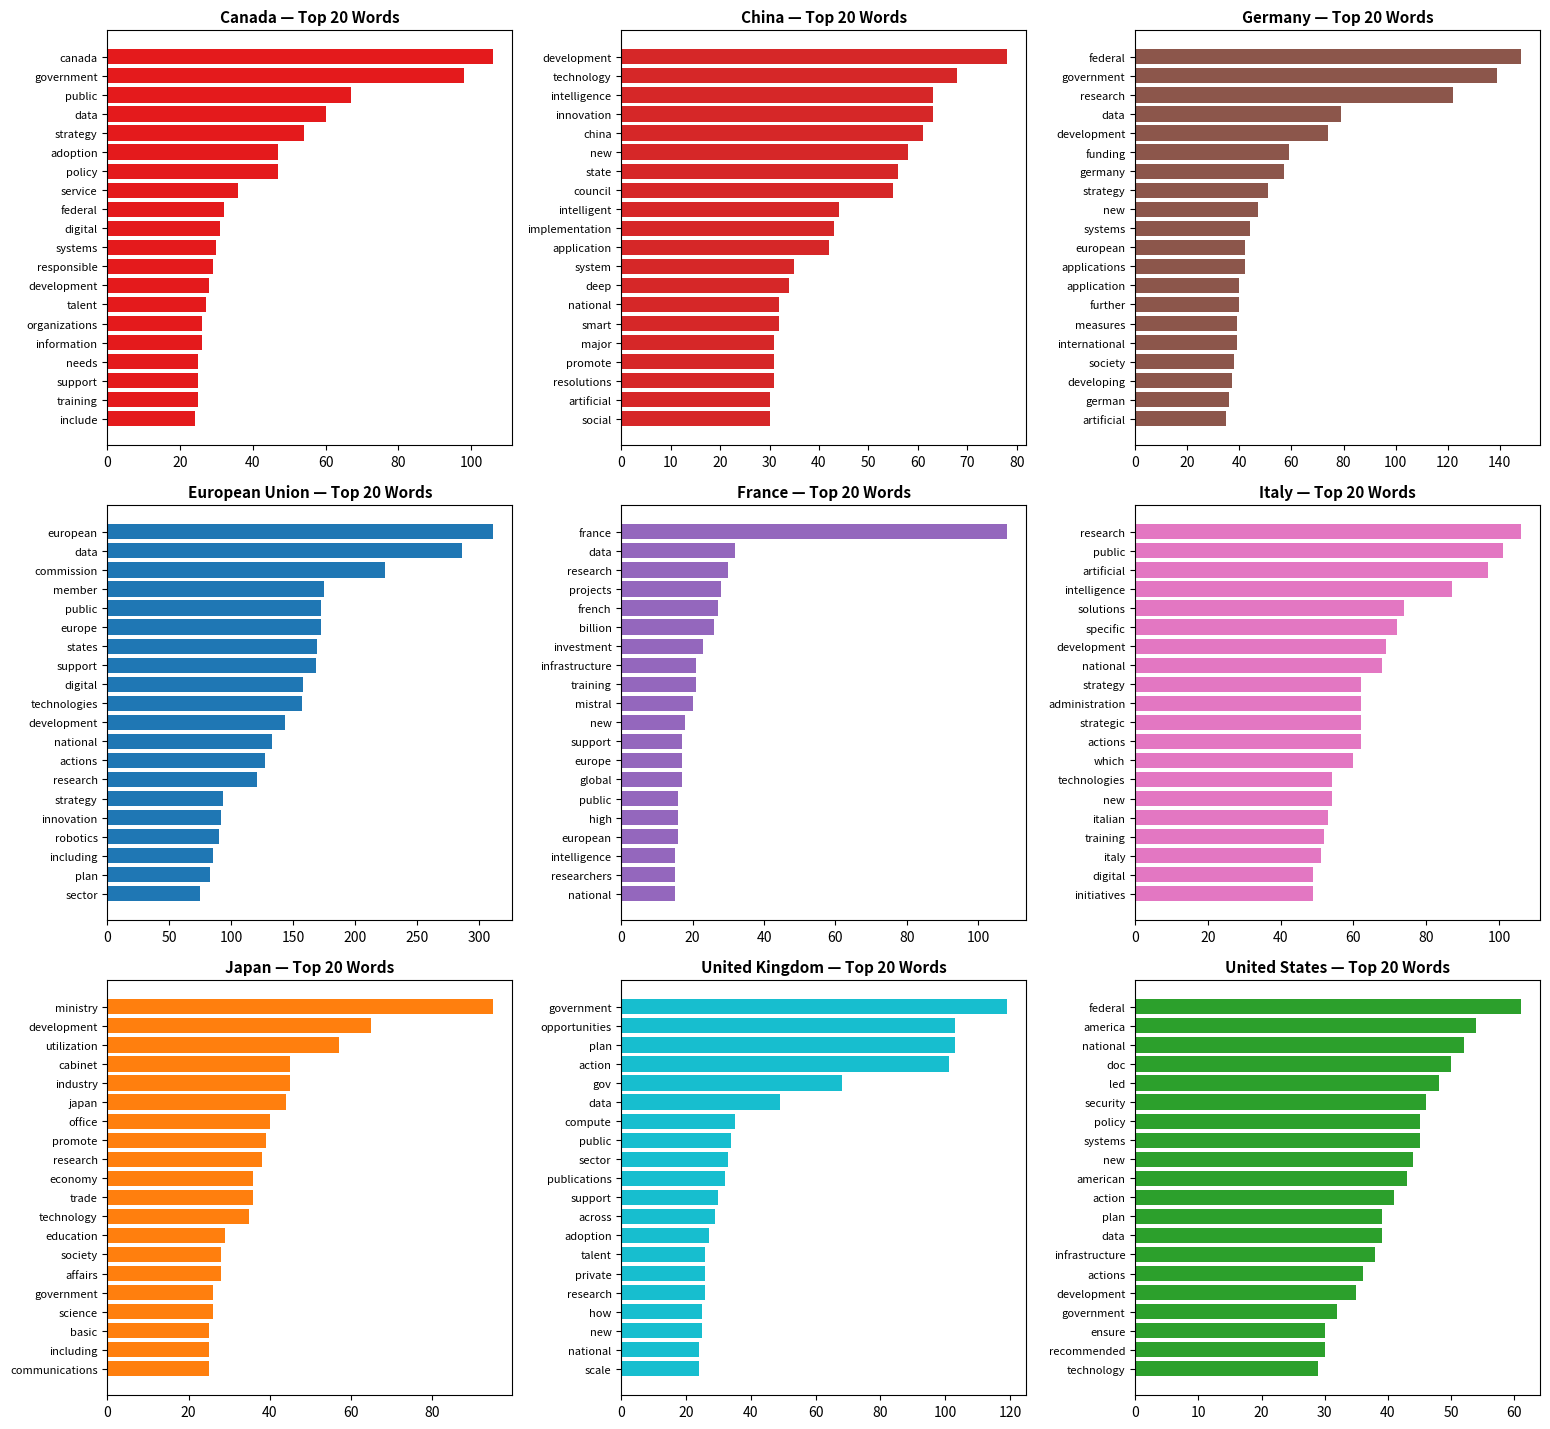

In [34]:
from ai_policy.text_utils import top_words

fig, axes = country_subplot_grid(len(analysis_texts), n_cols=3)

for ax, (country, text) in zip(axes, analysis_texts.items()):
    top = top_words(text, ALL_STOP, n=20)
    words = [w for w, _ in top][::-1]
    counts = [c for _, c in top][::-1]
    ax.barh(words, counts, color=COLORS[country])
    ax.set_title(f'{country} — Top 20 Words', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


## 8. TF-IDF — What's Distinctive About Each Country?

TF-IDF identifies words that are *unusually frequent* in one document relative to the others.


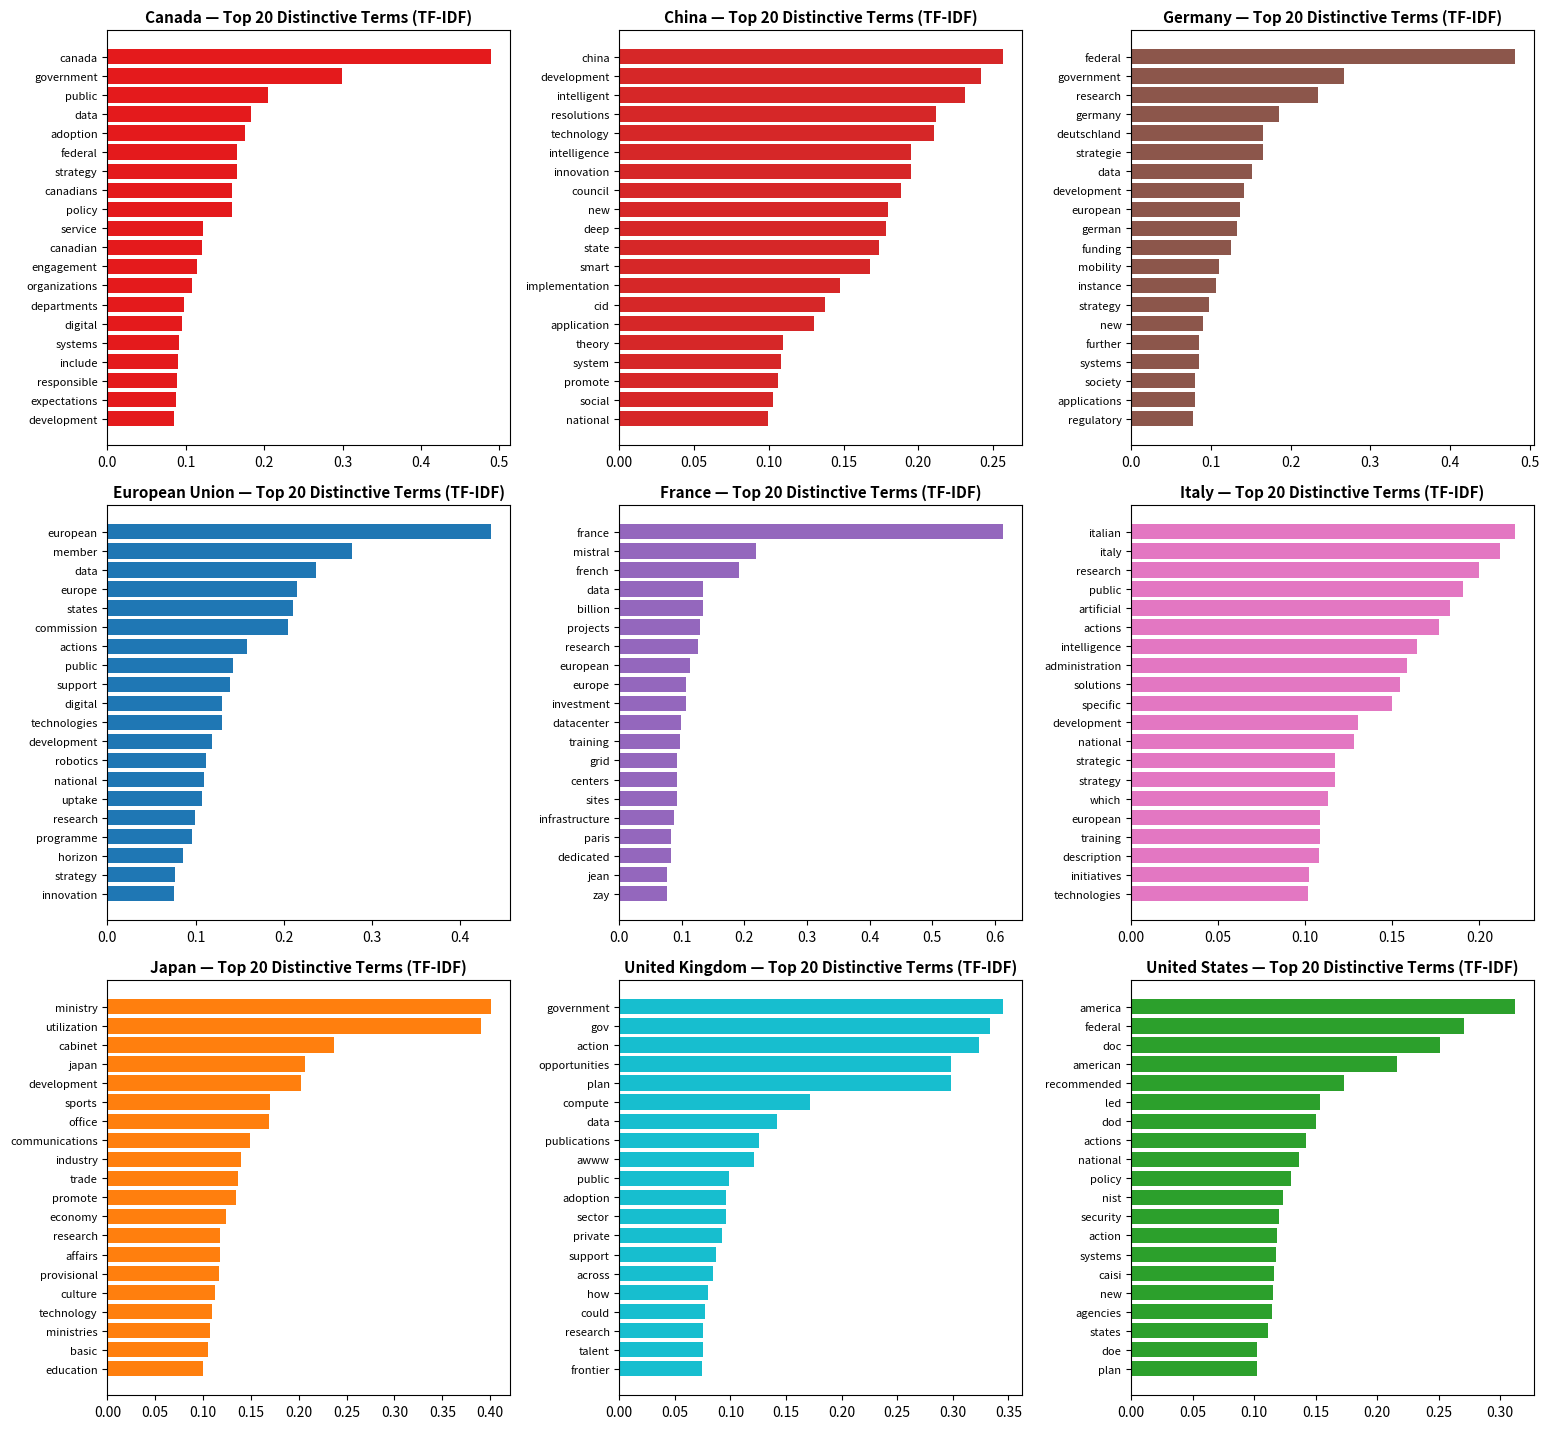

In [35]:
docs = [analysis_texts[c] for c in analysis_texts.keys()]
countries = list(analysis_texts.keys())

vec = TfidfVectorizer(
    stop_words=list(ALL_STOP),
    token_pattern=r"[a-zA-Zà-ÿÀ-ÝäöüÄÖÜß']{3,}",
    max_features=2000,
    lowercase=True,
)
tfidf = vec.fit_transform(docs)
vocab = vec.get_feature_names_out()

# Top distinctive words per country
fig, axes = country_subplot_grid(len(countries), n_cols=3)

for ax, (i, country) in zip(axes, enumerate(countries)):
    row = tfidf[i].toarray().flatten()
    top_idx = row.argsort()[-20:][::-1]
    words = [vocab[j] for j in top_idx][::-1]
    scores = [row[j] for j in top_idx][::-1]
    ax.barh(words, scores, color=COLORS[country])
    ax.set_title(f'{country} — Top 20 Distinctive Terms (TF-IDF)',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


## 9. Document Similarity (Cosine on TF-IDF)

How similar are the strategies to one another?


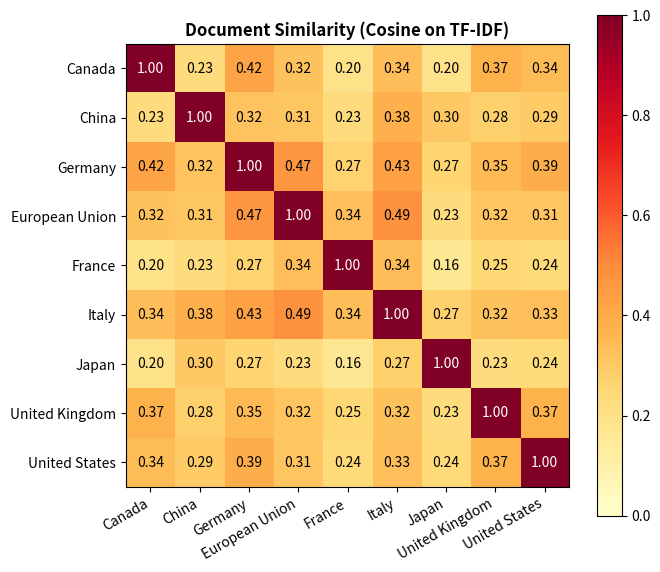

,Canada,China,Germany,European Union,France,Italy,Japan,United Kingdom,United States
Canada,1.000,0.231,0.417,0.321,0.195,0.336,0.195,0.372,0.343
China,0.231,1.000,0.318,0.311,0.230,0.382,0.302,0.279,0.294
Germany,0.417,0.318,1.000,0.468,0.268,0.432,0.265,0.350,0.389
European Union,0.321,0.311,0.468,1.000,0.335,0.486,0.234,0.316,0.314
France,0.195,0.230,0.268,0.335,1.000,0.338,0.164,0.252,0.240
Italy,0.336,0.382,0.432,0.486,0.338,1.000,0.274,0.324,0.333
Japan,0.195,0.302,0.265,0.234,0.164,0.274,1.000,0.230,0.242
United Kingdom,0.372,0.279,0.350,0.316,0.252,0.324,0.230,1.000,0.374
United States,0.343,0.294,0.389,0.314,0.240,0.333,0.242,0.374,1.000


In [36]:
sim_matrix = cosine_similarity(tfidf)
sim_df = pd.DataFrame(sim_matrix, index=countries, columns=countries).round(3)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_df.values, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(countries)))
ax.set_xticklabels(countries, rotation=30, ha='right')
ax.set_yticks(range(len(countries)))
ax.set_yticklabels(countries)
ax.set_title('Document Similarity (Cosine on TF-IDF)', fontweight='bold')

for i in range(len(countries)):
    for j in range(len(countries)):
        ax.text(j, i, f'{sim_df.values[i,j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='white' if sim_df.values[i,j] > 0.5 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
sim_df


## 10. Theme Keyword Tracking

Search how often each strategy mentions specific policy themes.


In [37]:
# Theme keywords are English-only because downstream analysis uses translated English text.
THEMES = {
    'Innovation':    ['innovation', 'innovative', 'innovate', 'artificial intelligence', 'ai'],
    'Investment':    ['investment', 'investing', 'fund', 'funding', 'capital'],
    'Ethics':        ['ethics', 'ethical', 'responsible', 'trustworthy'],
    'Regulation':    ['regulation', 'regulatory', 'governance', 'standard', 'compliance'],
    'Safety/Risk':   ['safety', 'risk', 'secure', 'security', 'harm'],
    'Talent/Skills': ['talent', 'skill', 'workforce', 'education', 'training'],
    'Research':      ['research', 'science', 'scientific', 'development'],
    'Industry':      ['industry', 'industrial', 'business', 'enterprise'],
    'Privacy/Data':  ['privacy', 'data protection', 'data', 'personal information'],
    'National Sec.': ['national security', 'defense', 'security'],
}


from ai_policy.text_utils import count_theme


theme_counts = pd.DataFrame(
    {country: {theme: count_theme(analysis_texts[country], kws) for theme, kws in THEMES.items()}
     for country in countries}
)

# Normalize per 1000 words to compare across documents of different lengths
word_counts = pd.Series({c: len(word_tokenize(analysis_texts[c])) for c in countries})
theme_norm = (theme_counts.div(word_counts) * 1000).round(2)

print('Raw counts:')
display(theme_counts)
print('\nPer 1000 words:')
display(theme_norm)



Raw counts:


,Canada,China,Germany,European Union,France,Italy,Japan,United Kingdom,United States
Innovation,336,353,766,1583,291,662,101,176,470
Investment,12,15,135,238,53,80,15,54,43
Ethics,37,10,32,105,1,20,18,3,4
Regulation,31,45,71,130,3,50,21,25,54
Safety/Risk,63,40,73,156,18,70,47,46,88
Talent/Skills,75,38,48,152,53,179,45,80,74
Research,46,143,262,315,70,204,136,71,104
Industry,18,57,62,107,14,94,67,24,30
Privacy/Data,82,28,88,317,49,56,28,56,50
National Sec.,21,23,30,62,14,16,25,20,89



Per 1000 words:


,Canada,China,Germany,European Union,France,Italy,Japan,United Kingdom,United States
Innovation,50.89,61.40,65.99,59.78,59.75,44.38,20.95,23.95,60.60
Investment,1.82,2.61,11.63,8.99,10.88,5.36,3.11,7.35,5.54
Ethics,5.60,1.74,2.76,3.97,0.21,1.34,3.73,0.41,0.52
Regulation,4.70,7.83,6.12,4.91,0.62,3.35,4.36,3.40,6.96
Safety/Risk,9.54,6.96,6.29,5.89,3.70,4.69,9.75,6.26,11.35
Talent/Skills,11.36,6.61,4.14,5.74,10.88,12.00,9.33,10.89,9.54
Research,6.97,24.87,22.57,11.90,14.37,13.68,28.21,9.66,13.41
Industry,2.73,9.91,5.34,4.04,2.87,6.30,13.90,3.27,3.87
Privacy/Data,12.42,4.87,7.58,11.97,10.06,3.75,5.81,7.62,6.45
National Sec.,3.18,4.00,2.58,2.34,2.87,1.07,5.19,2.72,11.47


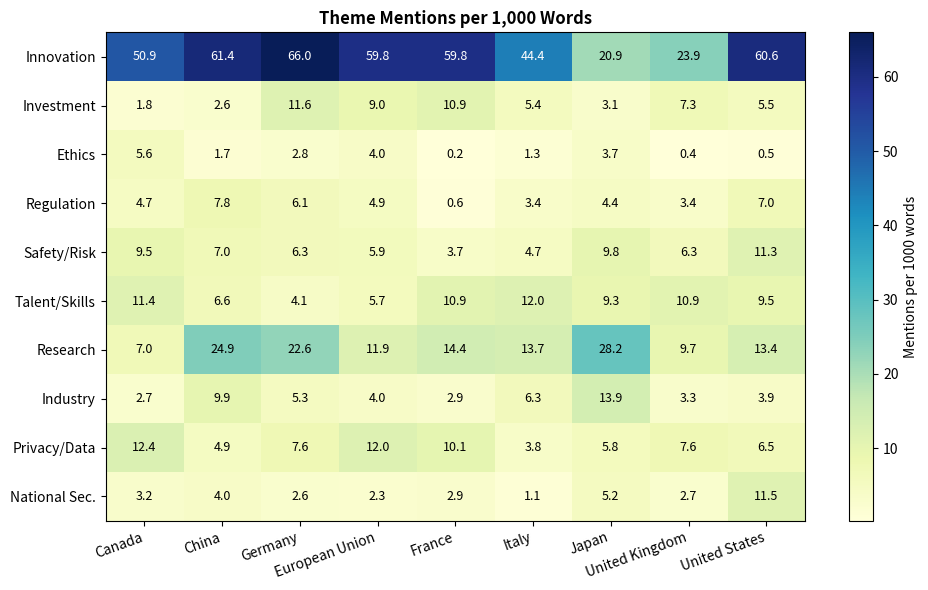

In [38]:
# Heatmap of normalized theme presence
outputs_dir = repo_root / 'outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(theme_norm.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(len(countries)))
ax.set_xticklabels(countries, rotation=20, ha='right')
ax.set_yticks(range(len(theme_norm.index)))
ax.set_yticklabels(theme_norm.index)
ax.set_title('Theme Mentions per 1,000 Words', fontweight='bold')

for i in range(len(theme_norm.index)):
    for j in range(len(countries)):
        v = theme_norm.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                fontsize=9, color='white' if v > theme_norm.values.max()*0.5 else 'black')

plt.colorbar(im, ax=ax, label='Mentions per 1000 words')
plt.tight_layout()
fig.savefig(outputs_dir / 'theme_mentions_per_1000_words.png', dpi=300, bbox_inches='tight')
plt.show()


## 11. Framing Keyword Analysis

Counts keywords associated with innovation-oriented and restriction/risk-oriented policy framing, then scores each strategy document by raw frequency, mentions per 1,000 words, and share of all framing keyword mentions.


In [39]:
FRAMING_KEYWORDS = {
    'Innovation-oriented': [
        'opportunity',
        'growth',
        'competitiveness',
        'innovation',
        'investment',
        'leadership',
        'acceleration',
        'adoption',
        'productivity',
        'development',
    ],
    'Restriction/risk-oriented': [
        'risk',
        'safety',
        'safeguard',
        'restriction',
        'compliance',
        'constraint',
        'oversight',
        'accountability',
        'transparency',
        'harm',
    ],
}


from ai_policy.text_utils import count_exact_keyword

framing_keyword_records = []
for country in countries:
    for framing, keywords in FRAMING_KEYWORDS.items():
        for keyword in keywords:
            framing_keyword_records.append({
                'Country': country,
                'Framing': framing,
                'Keyword': keyword,
                'Count': count_exact_keyword(analysis_texts[country], keyword),
            })

framing_keyword_counts = pd.DataFrame(framing_keyword_records)
framing_keyword_matrix = framing_keyword_counts.pivot_table(
    index=['Framing', 'Keyword'],
    columns='Country',
    values='Count',
    aggfunc='sum',
    fill_value=0,
)[countries]

framing_category_counts = framing_keyword_counts.pivot_table(
    index='Country',
    columns='Framing',
    values='Count',
    aggfunc='sum',
    fill_value=0,
).reindex(countries)

framing_scores_per_1000 = (
    framing_category_counts.div(word_counts, axis=0) * 1000
).round(2)

framing_share = framing_category_counts.div(
    framing_category_counts.sum(axis=1).replace(0, np.nan),
    axis=0,
).fillna(0).round(3)

framing_scores = pd.concat(
    {
        'raw_count': framing_category_counts,
        'per_1000_words': framing_scores_per_1000,
        'share_of_framing_mentions': framing_share,
    },
    axis=1,
)

print('Keyword counts by framing:')
display(framing_keyword_matrix)

print('\nDocument framing scores:')
display(framing_scores)


Keyword counts by framing:


Country                                    Canada  China  Germany  \
Framing                   Keyword                                   
Innovation-oriented       acceleration          0      0        1   
                          adoption             47      0        0   
                          competitiveness       1      4        8   
                          development          28     78       74   
                          growth                2      4        3   
                          innovation            5     63       35   
                          investment            3      0        2   
                          leadership            2      5        1   
                          opportunity           3      3        2   
                          productivity          4      1        3   
Restriction/risk-oriented accountability        4      2        0   
                          compliance            3      1        4   
                          constraint            0      0        0   
                          harm                  0      0        1   
                          oversight             3      0        0   
                          restriction           0      0        0   
                          risk                 16      6        1   
                          safeguard             2      0        0   
                          safety                2     10       17   
                          transparency         10      1        6   

Country                                    European Union  France  Italy  \
Framing                   Keyword                                          
Innovation-oriented       acceleration                  2       2      3   
                          adoption                     24       4     26   
                          competitiveness               8       1     14   
                          development                 143      12     69   
                          growth                        9       6      7   
                          innovation                   90      13     33   
                          investment                   34      23      4   
                          leadership                   16       1      0   
                          opportunity                  10       2      5   
                          productivity                  1       0      5   
Restriction/risk-oriented accountability                2       0      0   
                          compliance                    6       0     11   
                          constraint                    0       0      0   
                          harm                          1       0      0   
                          oversight                     2       0      0   
                          restriction                   0       0      0   
                          risk                         11       0     27   
                          safeguard                     0       0      0   
                          safety                       40       2      5   
                          transparency                  7       0      4   

Country                                    Japan  United Kingdom  \
Framing                   Keyword                                  
Innovation-oriented       acceleration         0               1   
                          adoption             1              27   
                          competitiveness      2               1   
                          development         65              14   
                          growth               4              21   
                          innovation          16              23   
                          investment           9              15   
                          leadership           1               4   
                          opportunity          1               6   
                          productivity         1            


Document framing scores:


raw_count                            \
Framing        Innovation-oriented Restriction/risk-oriented   
Country                                                        
Canada                          95                        40   
China                          158                        20   
Germany                        129                        29   
European Union                 337                        69   
France                          64                         2   
Italy                          166                        47   
Japan                          100                        16   
United Kingdom                 119                        19   
United States                  108                        13   

                    per_1000_words                            \
Framing        Innovation-oriented Restriction/risk-oriented   
Country                                                        
Canada                       14.39                      6.06   
China                        27.48                      3.48   
Germany                      11.11                      2.50   
European Union               12.73                      2.61   
France                       13.14                      0.41   
Italy                        11.13                      3.15   
Japan                        20.74                      3.32   
United Kingdom               16.19                      2.59   
United States                13.92                      1.68   

               share_of_framing_mentions                            
Framing              Innovation-oriented Restriction/risk-oriented  
Country                                                             
Canada                             0.704                     0.296  
China                              0.888                     0.112  
Germany                            0.816                     0.184  
European Union                     0.830                     0.170  
France                             0.970                     0.030  
Italy                              0.779                     0.221  
Japan                              0.862                     0.138  
United Kingdom                     0.862                     0.138  
United States                      0.893                     0.107

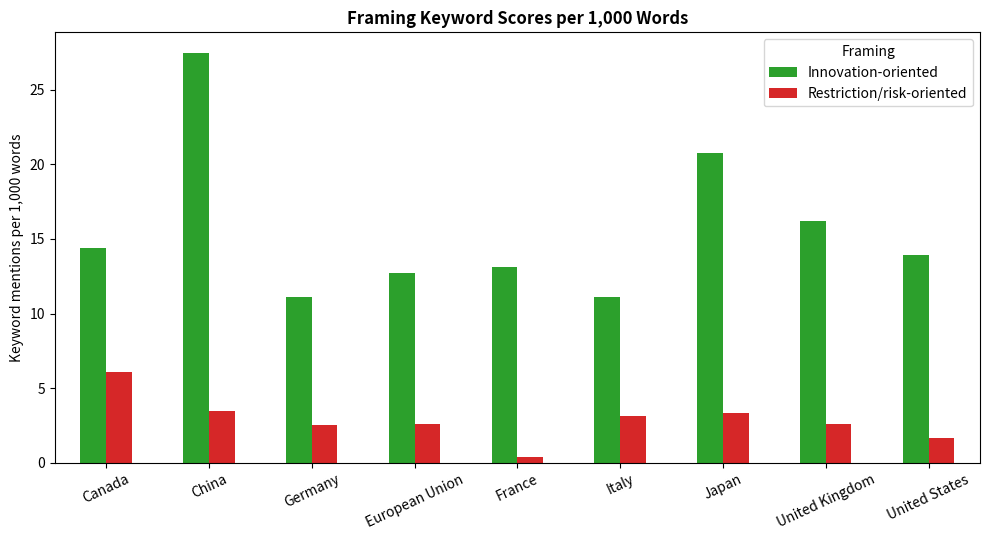

In [40]:
outputs_dir = repo_root / 'outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
framing_scores_per_1000.plot(
    kind='bar',
    ax=ax,
    color=['#2ca02c', '#d62728'],
)
ax.set_title('Framing Keyword Scores per 1,000 Words', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Keyword mentions per 1,000 words')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Framing', loc='upper right')
plt.tight_layout()
fig.savefig(outputs_dir / 'framing_keyword_scores_per_1000_words.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Keyword Heatmap

Visualize how often each framing keyword appears in each national AI strategy document.

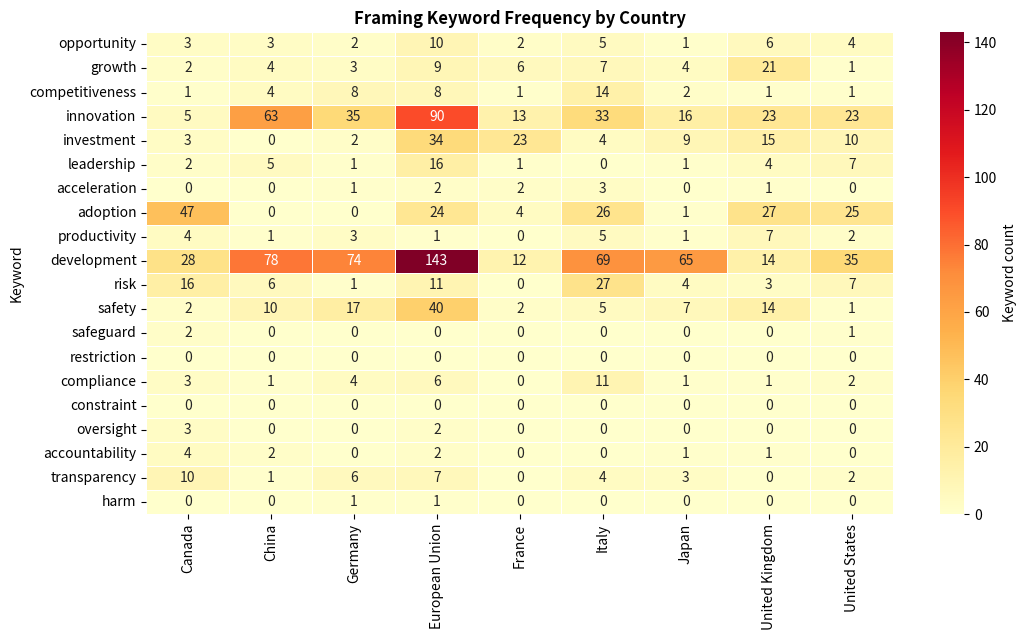

In [41]:
import seaborn as sns

outputs_dir = repo_root / 'outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

keyword_heatmap = framing_keyword_counts.pivot_table(
    index='Keyword',
    columns='Country',
    values='Count',
    aggfunc='sum',
    fill_value=0,
).reindex(
    [kw for keywords in FRAMING_KEYWORDS.values() for kw in keywords]
)[countries]

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(
    keyword_heatmap,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Keyword count'},
    ax=ax,
)
ax.set_title('Framing Keyword Frequency by Country', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Keyword')
plt.tight_layout()
fig.savefig(outputs_dir / 'framing_keyword_frequency_by_country.png', dpi=300, bbox_inches='tight')
plt.show()


## 13. Country → Framing → Keyword Sankey

Trace each country's keyword mentions into framing categories and then into the specific keywords driving each frame.

In [42]:
import plotly.graph_objects as go

sankey_rows = framing_keyword_counts[framing_keyword_counts['Count'] > 0].copy()

country_nodes = countries
framing_nodes = list(FRAMING_KEYWORDS.keys())
keyword_nodes = [kw for keywords in FRAMING_KEYWORDS.values() for kw in keywords]
node_labels = country_nodes + framing_nodes + keyword_nodes
node_index = {label: i for i, label in enumerate(node_labels)}

sources = []
targets = []
values = []
link_colors = []

for country in countries:
    for framing in framing_nodes:
        count = int(framing_category_counts.loc[country, framing])
        if count > 0:
            sources.append(node_index[country])
            targets.append(node_index[framing])
            values.append(count)
            link_colors.append('rgba(80, 80, 80, 0.22)')

framing_colors = {
    'Innovation-oriented': 'rgba(44, 160, 44, 0.35)',
    'Restriction/risk-oriented': 'rgba(214, 39, 40, 0.35)',
}
for _, row in sankey_rows.iterrows():
    sources.append(node_index[row['Framing']])
    targets.append(node_index[row['Keyword']])
    values.append(int(row['Count']))
    link_colors.append(framing_colors[row['Framing']])

node_colors = []
for label in node_labels:
    if label in COLORS:
        node_colors.append(COLORS[label])
    elif label == 'Innovation-oriented':
        node_colors.append('#2ca02c')
    elif label == 'Restriction/risk-oriented':
        node_colors.append('#d62728')
    else:
        node_colors.append('#9edae5')

sankey_fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=18,
        thickness=16,
        line=dict(color='rgba(0,0,0,0.25)', width=0.5),
        label=node_labels,
        color=node_colors,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    ),
)])

sankey_fig.update_layout(
    title_text='Country → Framing → Keyword Mentions',
    font_size=11,
    height=650,
    margin=dict(l=20, r=20, t=60, b=20),
)
sankey_fig.show()


## 14. Sentence Explorer

Find the original sentences where each framing keyword appears. Use the widgets to filter by country, framing category, and keyword.

In [43]:
from IPython.display import HTML

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None


from ai_policy.text_utils import filter_keyword_sentences, keyword_sentence_table_html, split_sentences

sentence_records = []
for country, text in analysis_texts.items():
    for sentence in split_sentences(text):
        for framing, keywords in FRAMING_KEYWORDS.items():
            for keyword in keywords:
                if count_exact_keyword(sentence, keyword) > 0:
                    sentence_records.append({
                        'Country': country,
                        'Framing': framing,
                        'Keyword': keyword,
                        'Sentence': sentence,
                    })

keyword_sentence_matches = pd.DataFrame(sentence_records)
print(f'Keyword sentence matches: {len(keyword_sentence_matches)}')
display(keyword_sentence_matches.head(10))


def get_keyword_sentences(country='All', framing='All', keyword='All', max_results=25):
    return filter_keyword_sentences(
        keyword_sentence_matches,
        country=country,
        framing=framing,
        keyword=keyword,
        max_results=max_results,
    )


def show_keyword_sentences(country='All', framing='All', keyword='All', max_results=25):
    df = get_keyword_sentences(country, framing, keyword, max_results)
    if df.empty:
        display(HTML('<p>No matching sentences found.</p>'))
        return

    html = keyword_sentence_table_html(df)
    display(HTML(html))


if widgets is not None:
    country_dropdown = widgets.Dropdown(options=['All'] + countries, value='All', description='Country')
    framing_dropdown = widgets.Dropdown(options=['All'] + list(FRAMING_KEYWORDS.keys()), value='All', description='Framing')
    keyword_dropdown = widgets.Dropdown(
        options=['All'] + [kw for keywords in FRAMING_KEYWORDS.values() for kw in keywords],
        value='All',
        description='Keyword',
    )
    max_slider = widgets.IntSlider(value=25, min=5, max=100, step=5, description='Rows')
    output = widgets.Output()

    def refresh_sentences(*_):
        with output:
            output.clear_output(wait=True)
            show_keyword_sentences(
                country_dropdown.value,
                framing_dropdown.value,
                keyword_dropdown.value,
                max_slider.value,
            )

    for control in [country_dropdown, framing_dropdown, keyword_dropdown, max_slider]:
        control.observe(refresh_sentences, names='value')

    display(widgets.VBox([
        widgets.HBox([country_dropdown, framing_dropdown, keyword_dropdown, max_slider]),
        output,
    ]))
    refresh_sentences()
else:
    show_keyword_sentences(max_results=25)


Keyword sentence matches: 1372


,Country,Framing,Keyword,Sentence
0,Canada,Innovation-oriented,adoption,Aussi offert en frangais sous le titre : Strat...
1,Canada,Innovation-oriented,productivity,It can increase the public service's efficienc...
2,Canada,Innovation-oriented,growth,"Its generative Al tool, AgPal Chat, helps user..."
3,Canada,Innovation-oriented,competitiveness,"Its generative Al tool, AgPal Chat, helps user..."
4,Canada,Innovation-oriented,innovation,"Transcribing and summarizing: Innovation, Scie..."
5,Canada,Innovation-oriented,development,"Transcribing and summarizing: Innovation, Scie..."
6,Canada,Innovation-oriented,productivity,Increasing productivity: Shared Services Canad...
7,Canada,Restriction/risk-oriented,safety,The use of AI has enabled a tenfold increase i...
8,Canada,Innovation-oriented,adoption,"Beyond ethical and security concerns, challeng..."
9,Canada,Restriction/risk-oriented,risk,Existing and future AI systems must therefore ...


## 15. Bigram Analysis — Top Phrases per Country


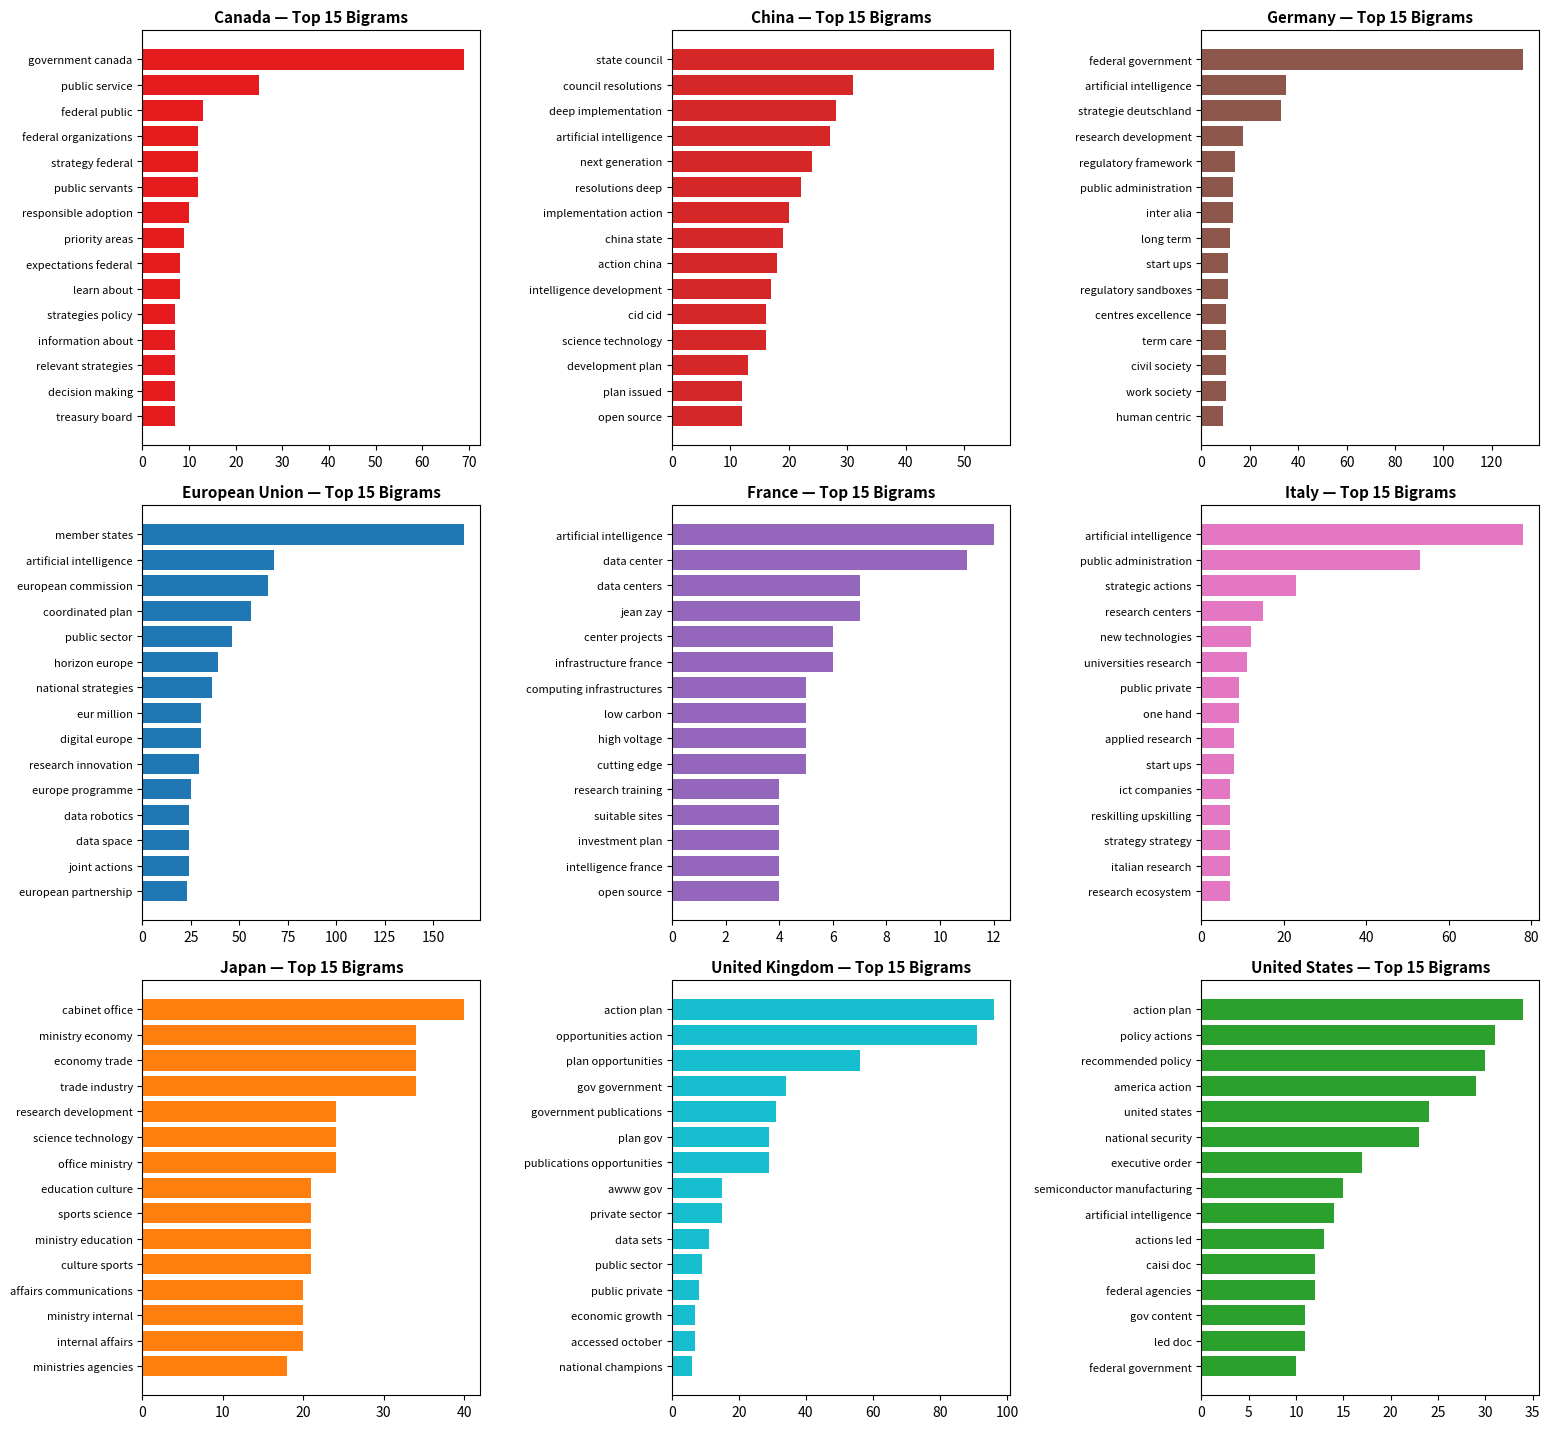

In [44]:
bg_vec = CountVectorizer(
    stop_words=list(ALL_STOP),
    token_pattern=r"[a-zA-Zà-ÿÀ-ÝäöüÄÖÜß']{3,}",
    ngram_range=(2, 2),
    max_features=2000,
)
bg = bg_vec.fit_transform(docs)
bg_vocab = bg_vec.get_feature_names_out()

fig, axes = country_subplot_grid(len(countries), n_cols=3)
for ax, (i, country) in zip(axes, enumerate(countries)):
    row = bg[i].toarray().flatten()
    top_idx = row.argsort()[-15:][::-1]
    phrases = [bg_vocab[j] for j in top_idx][::-1]
    counts = [row[j] for j in top_idx][::-1]
    ax.barh(phrases, counts, color=COLORS[country])
    ax.set_title(f'{country} — Top 15 Bigrams', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


## 16. Topic Modeling (LDA)

Discover latent topics across all 4 documents.


In [45]:
# CountVectorizer for LDA
ct_vec = CountVectorizer(
    stop_words=list(ALL_STOP),
    token_pattern=r"[a-zA-Zà-ÿÀ-ÝäöüÄÖÜß']{3,}",
    max_features=1500,
    min_df=2,
    max_df=0.95,
)
ct = ct_vec.fit_transform(docs)
ct_vocab = ct_vec.get_feature_names_out()

n_topics = 4
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
doc_topic = lda.fit_transform(ct)

# Print top words per topic
print('Top words per topic:')
for i, topic in enumerate(lda.components_):
    top_words_topic = [ct_vocab[j] for j in topic.argsort()[-12:][::-1]]
    print(f'  Topic {i+1}: {", ".join(top_words_topic)}')

print()
topic_df = pd.DataFrame(doc_topic.round(3), index=countries,
                        columns=[f'Topic {i+1}' for i in range(n_topics)])
print('Topic distribution per document:')
display(topic_df)


Top words per topic:
  Topic 1: european, commission, europe, member, states, actions, robotics, health, policy, programme, trustworthy, joint
  Topic 2: action, canada, adoption, policy, federal, gov, ensure, how, america, doc, led, compute
  Topic 3: ministry, specific, solutions, promote, initiatives, administration, actions, utilization, education, training, italian, italy
  Topic 4: federal, france, china, implementation, projects, council, germany, promote, funding, social, society, intelligent

Topic distribution per document:


,Topic 1,Topic 2,Topic 3,Topic 4
Canada,0.000,1.000,0.000,0.000
China,0.000,0.000,0.000,1.000
Germany,0.217,0.000,0.000,0.783
European Union,1.000,0.000,0.000,0.000
France,0.042,0.168,0.071,0.719
Italy,0.000,0.000,1.000,0.000
Japan,0.000,0.000,1.000,0.000
United Kingdom,0.000,1.000,0.000,0.000
United States,0.000,1.000,0.000,0.000


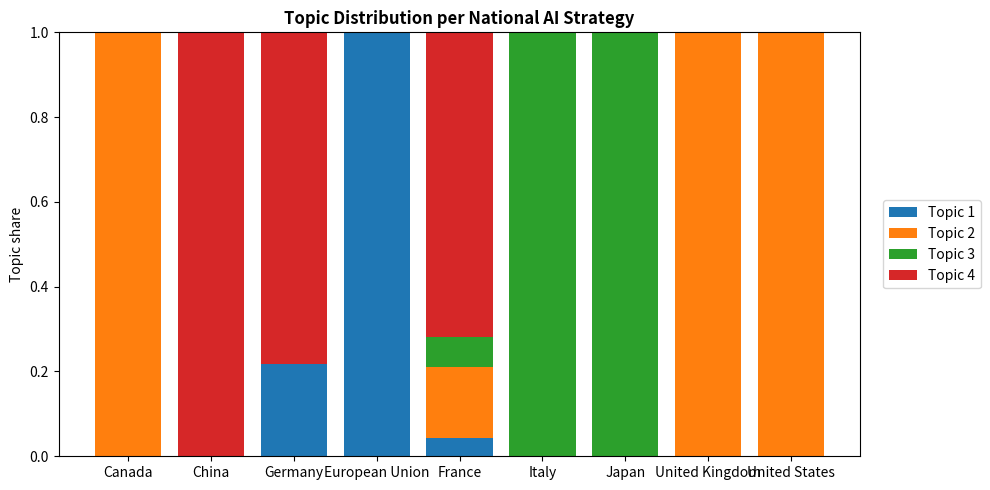

In [46]:
# Stacked bar of topic distribution
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(countries))
topic_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i in range(n_topics):
    vals = topic_df[f'Topic {i+1}'].values
    ax.bar(countries, vals, bottom=bottom, label=f'Topic {i+1}', color=topic_colors[i])
    bottom += vals

ax.set_ylabel('Topic share')
ax.set_title('Topic Distribution per National AI Strategy', fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


## 17. Save Cleaned Texts and Stats

In [47]:
out_dir = repo_root / 'data' / 'pdf' / 'AI Policy' / '_extracted'
out_dir.mkdir(parents=True, exist_ok=True)

for country, text in texts.items():
    (out_dir / f'{country}.txt').write_text(text, encoding='utf-8')

for country, text in analysis_texts.items():
    (out_dir / f'{country}_analysis_english.txt').write_text(text, encoding='utf-8')

stats_df.to_csv(out_dir / 'document_stats.csv')
pd.Series({country: '; '.join(files) for country, files in source_files.items()}, name='Source files').to_csv(out_dir / 'document_sources.csv')
pd.Series(analysis_text_source, name='Analysis text source').to_csv(out_dir / 'analysis_text_sources.csv')
theme_counts.to_csv(out_dir / 'theme_counts_raw.csv')
theme_norm.to_csv(out_dir / 'theme_per_1000_words.csv')
sim_df.to_csv(out_dir / 'similarity_matrix.csv')
framing_keyword_counts.to_csv(out_dir / 'framing_keyword_counts.csv', index=False)
framing_category_counts.to_csv(out_dir / 'framing_category_counts.csv')
framing_scores_per_1000.to_csv(out_dir / 'framing_scores_per_1000_words.csv')
framing_share.to_csv(out_dir / 'framing_share_of_mentions.csv')
keyword_sentence_matches.to_csv(out_dir / 'keyword_sentence_matches.csv', index=False)

print(f'Saved outputs to: {out_dir}')
for f in sorted(out_dir.iterdir()):
    print(f'  - {f.name}')


Saved outputs to: /home/wucheng/AI-Policy/data/pdf/AI Policy/_extracted
  - Canada.txt
  - Canada_analysis_english.txt
  - China.txt
  - China_analysis_english.txt
  - European Union.txt
  - European Union_analysis_english.txt
  - France.txt
  - France_analysis_english.txt
  - Germany.txt
  - Germany_analysis_english.txt
  - Italy.txt
  - Italy_analysis_english.txt
  - Japan.txt
  - Japan_analysis_english.txt
  - United Kingdom.txt
  - United Kingdom_analysis_english.txt
  - United States.txt
  - United States_analysis_english.txt
  - analysis_text_sources.csv
  - document_sources.csv
  - document_stats.csv
  - framing_category_counts.csv
  - framing_keyword_counts.csv
  - framing_scores_per_1000_words.csv
  - framing_share_of_mentions.csv
  - keyword_sentence_matches.csv
  - similarity_matrix.csv
  - theme_counts_raw.csv
  - theme_per_1000_words.csv


## What Else Can You Do?

- **Sentence-level extraction** — pull sentences mentioning specific themes for qualitative review
- **Named entity recognition** (spaCy) — extract organizations, locations, numbers
- **Sentiment analysis** — tone of policy language (more useful with multilingual models)
- **Cross-language alignment** — translate to one language first (DeepL / Google Translate API) for stronger comparison
- **Time-aware analysis** — if you have multiple versions per country (e.g. 2018 vs 2023), track wording changes
- **Citation-style network** — extract references and build a graph of who cites whom
